# SOCIAL MEDIA, SCREEN TIME AND MENTAL HEALTH 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve,ConfusionMatrixDisplay

)

In [3]:
from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from scipy.stats import percentileofscore

In [4]:
df = pd.read_csv("social_media_screentime_mental_health_2026.csv")

DATASET GENERAL OVERVIEW 

In [5]:
df.head()
# frist 5 rows

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


In [6]:
df.tail()
# last 5 rows

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
6995,P306995,30,Male,Part-time employed,Europe,Snapchat,4,3.6,74,Never,...,4,4,6,3,10,2,Yes,No,No,Good
6996,P306996,28,Male,Self-employed,North America,Facebook,3,5.0,104,Every night,...,8,1,7,6,7,1,No,"Yes, failed",No,Moderate
6997,P306997,26,Prefer not to say,Unemployed,Oceania,LinkedIn,3,1.2,25,Never,...,9,4,5,1,6,3,No,No,No,Good
6998,P306998,22,Female,Student,Europe,Snapchat,4,3.6,182,Sometimes,...,5,7,4,1,6,2,No,"Yes, failed",No,Good
6999,P306999,29,Male,Student,Asia,Facebook,1,5.8,14,Every night,...,5,7,4,9,6,3,No,No,Considering it,Moderate


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   participant_id                       7000 non-null   str    
 1   age                                  7000 non-null   int64  
 2   gender                               6930 non-null   str    
 3   occupation                           7000 non-null   str    
 4   region                               7000 non-null   str    
 5   most_used_platform                   7000 non-null   str    
 6   platforms_used_count                 7000 non-null   int64  
 7   daily_screen_hours                   7000 non-null   float64
 8   daily_notifications                  7000 non-null   int64  
 9   night_time_use                       7000 non-null   str    
 10  minutes_to_first_check_after_waking  7000 non-null   int64  
 11  primary_purpose                      7000

The dataset consists of 7,000 rows and 25 columns. Only two variables contain missing values: gender and avg_sleep_hours.

In [8]:
df.shape

(7000, 25)

In [9]:
df.columns

Index(['participant_id', 'age', 'gender', 'occupation', 'region',
       'most_used_platform', 'platforms_used_count', 'daily_screen_hours',
       'daily_notifications', 'night_time_use',
       'minutes_to_first_check_after_waking', 'primary_purpose',
       'avg_sleep_hours', 'anxiety_score_0to27', 'low_mood_score_0to27',
       'life_satisfaction_1to10', 'loneliness_1to10', 'self_esteem_1to10',
       'fomo_1to10', 'social_comparison_1to10',
       'physical_activity_days_per_week', 'uses_screen_time_limits',
       'attempted_digital_detox', 'seeks_mental_health_support',
       'wellbeing_band'],
      dtype='str')

In [10]:
df.dtypes

participant_id                             str
age                                      int64
gender                                     str
occupation                                 str
region                                     str
most_used_platform                         str
platforms_used_count                     int64
daily_screen_hours                     float64
daily_notifications                      int64
night_time_use                             str
minutes_to_first_check_after_waking      int64
primary_purpose                            str
avg_sleep_hours                        float64
anxiety_score_0to27                      int64
low_mood_score_0to27                     int64
life_satisfaction_1to10                  int64
loneliness_1to10                         int64
self_esteem_1to10                        int64
fomo_1to10                               int64
social_comparison_1to10                  int64
physical_activity_days_per_week          int64
uses_screen_t

In [11]:
# check if partecipant_id is unique: are there duplicates?
df["participant_id"].nunique()
df["participant_id"].duplicated().sum()

np.int64(0)

In [12]:
# are there duplicates for other variables?
df.duplicated().sum()

np.int64(0)

ABOUT SOME VARIABLES

Data Cleaning: are there missing values?

In [13]:
# missing count
df.isna().sum()

participant_id                           0
age                                      0
gender                                  70
occupation                               0
region                                   0
most_used_platform                       0
platforms_used_count                     0
daily_screen_hours                       0
daily_notifications                      0
night_time_use                           0
minutes_to_first_check_after_waking      0
primary_purpose                          0
avg_sleep_hours                        105
anxiety_score_0to27                      0
low_mood_score_0to27                     0
life_satisfaction_1to10                  0
loneliness_1to10                         0
self_esteem_1to10                        0
fomo_1to10                               0
social_comparison_1to10                  0
physical_activity_days_per_week          0
uses_screen_time_limits                  0
attempted_digital_detox                  0
seeks_menta

In [14]:
# missing percentage
(df.isna().mean()*100).sort_values()
# low percentage of missing: 1% for gender, 1.5% for avg_sleep_hours

participant_id                         0.0
age                                    0.0
occupation                             0.0
region                                 0.0
platforms_used_count                   0.0
most_used_platform                     0.0
daily_screen_hours                     0.0
daily_notifications                    0.0
anxiety_score_0to27                    0.0
night_time_use                         0.0
minutes_to_first_check_after_waking    0.0
primary_purpose                        0.0
life_satisfaction_1to10                0.0
low_mood_score_0to27                   0.0
self_esteem_1to10                      0.0
loneliness_1to10                       0.0
wellbeing_band                         0.0
uses_screen_time_limits                0.0
fomo_1to10                             0.0
social_comparison_1to10                0.0
physical_activity_days_per_week        0.0
seeks_mental_health_support            0.0
attempted_digital_detox                0.0
gender     

In [15]:
# describe per numerical variable
df["avg_sleep_hours"].describe()

count    6895.000000
mean        6.964989
std         0.870575
min         3.800000
25%         6.400000
50%         7.000000
75%         7.600000
max        10.000000
Name: avg_sleep_hours, dtype: float64

<Axes: >

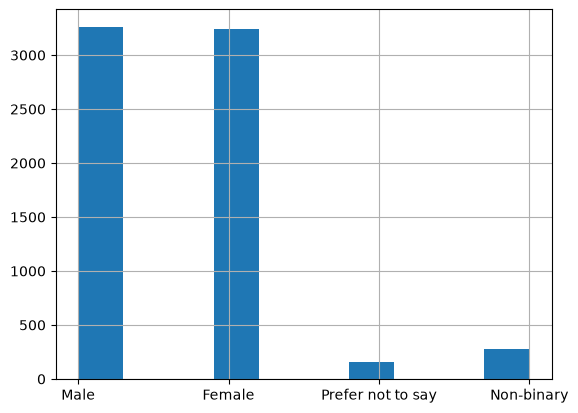

In [16]:
# histogram for categorical one
df["gender"].hist()

In [17]:
df["gender"].value_counts()

gender
Male                 3261
Female               3240
Non-binary            276
Prefer not to say     153
Name: count, dtype: int64

Nature of missing values
- MCAR (Missing Completely At Random) → completely missing values
- MAR (Missing At Random) → depend on other variables
- MNAR (Missing Not At Random) → depend on missing value

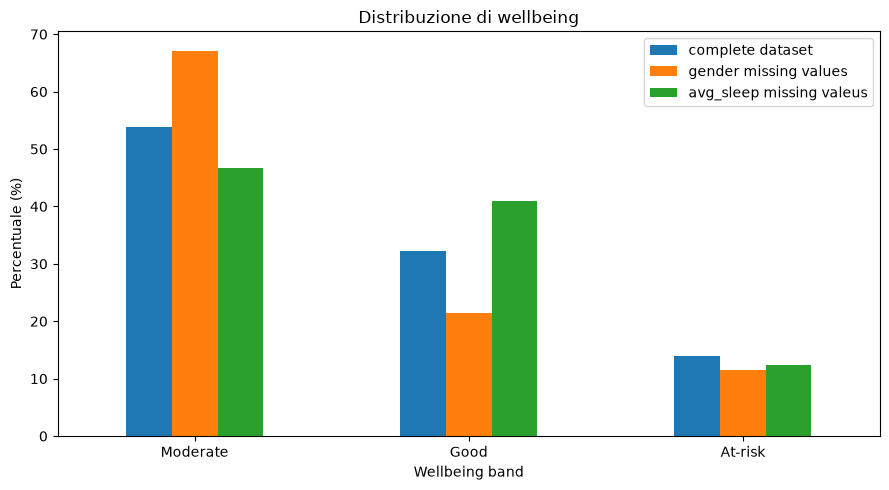

In [18]:
comparison = pd.DataFrame({
    "complete dataset": df["wellbeing_band"].value_counts(normalize=True) * 100,
    "gender missing values": df.loc[df["gender"].isna(), "wellbeing_band"].value_counts(normalize=True) * 100,
    "avg_sleep missing valeus": df.loc[df["avg_sleep_hours"].isna(), "wellbeing_band"].value_counts(normalize=True) * 100
})

comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Distribuzione di wellbeing")
plt.xlabel("Wellbeing band")
plt.ylabel("Percentuale (%)")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
df["wellbeing_band"].value_counts(normalize=True) * 100

wellbeing_band
Moderate    53.800000
Good        32.285714
At-risk     13.914286
Name: proportion, dtype: float64

In [20]:
df[df["gender"].isna()]["wellbeing_band"].value_counts(normalize=True) * 100

wellbeing_band
Moderate    67.142857
Good        21.428571
At-risk     11.428571
Name: proportion, dtype: float64

In [21]:
df[df["avg_sleep_hours"].isna()]["wellbeing_band"].value_counts(normalize=True) * 100

wellbeing_band
Moderate    46.666667
Good        40.952381
At-risk     12.380952
Name: proportion, dtype: float64

In [22]:
df["gender_missing"] = df["gender"].isna()

In [23]:
df.groupby("gender_missing")[
    ["age", "daily_screen_hours", "daily_notifications", "anxiety_score_0to27"]
].mean()

,age,daily_screen_hours,daily_notifications,anxiety_score_0to27
gender_missing,,,,
False,29.250072,3.305815,61.552092,11.375469
True,28.900000,3.221429,59.171429,11.628571


In [24]:
df["sleep_missing"] = df["avg_sleep_hours"].isna()

In [25]:
df.groupby("sleep_missing")[
    ["age", "daily_screen_hours", "daily_notifications", "anxiety_score_0to27"]
].mean()

,age,daily_screen_hours,daily_notifications,anxiety_score_0to27
sleep_missing,,,,
False,29.227556,3.309471,61.719942,11.386367
True,30.495238,3.009524,48.942857,10.828571


The missing values in gender do not appear to be associated with observable characteristics such as age or daily screen time. The similar distributions between missing and non-missing groups suggest that the missing mechanism may be consistent with MCAR; however, further checks involving additional numerical and categorical variables are required.

In [26]:
df.groupby("sleep_missing").mean(numeric_only=True).T

sleep_missing,False,True
age,29.227556,30.495238
platforms_used_count,3.494416,3.504762
daily_screen_hours,3.309471,3.009524
daily_notifications,61.719942,48.942857
minutes_to_first_check_after_waking,19.992313,21.057143
avg_sleep_hours,6.964989,NaN
anxiety_score_0to27,11.386367,10.828571
low_mood_score_0to27,3.844815,3.904762
life_satisfaction_1to10,6.955910,6.952381
loneliness_1to10,4.683394,4.409524


In [27]:
df.columns

Index(['participant_id', 'age', 'gender', 'occupation', 'region',
       'most_used_platform', 'platforms_used_count', 'daily_screen_hours',
       'daily_notifications', 'night_time_use',
       'minutes_to_first_check_after_waking', 'primary_purpose',
       'avg_sleep_hours', 'anxiety_score_0to27', 'low_mood_score_0to27',
       'life_satisfaction_1to10', 'loneliness_1to10', 'self_esteem_1to10',
       'fomo_1to10', 'social_comparison_1to10',
       'physical_activity_days_per_week', 'uses_screen_time_limits',
       'attempted_digital_detox', 'seeks_mental_health_support',
       'wellbeing_band', 'gender_missing', 'sleep_missing'],
      dtype='str')

We can drop missing values, because there aren't patterns and the percentage of missing is very low.

In [28]:
df_clean = df.dropna()

In [29]:
df_clean.shape

(6827, 27)

Ckeck range and cardinality

In [30]:
df_clean.describe()

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
count,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000
mean,29.230409,3.494947,3.310078,61.735902,20.022411,6.964523,11.383477,3.851472,6.955764,4.688736,6.002637,4.641131,5.326791,2.806650
std,9.576428,1.760681,1.884573,54.995025,13.972796,0.871917,4.777929,3.539476,1.616310,2.093184,1.887006,2.158690,2.091586,1.287592
min,13.000000,1.000000,0.200000,5.000000,0.000000,3.800000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,22.000000,2.000000,1.900000,24.000000,10.000000,6.400000,8.000000,0.000000,6.000000,3.000000,5.000000,3.000000,4.000000,2.000000
50%,29.000000,3.000000,3.000000,46.000000,17.000000,7.000000,11.000000,3.000000,7.000000,5.000000,6.000000,5.000000,5.000000,3.000000
75%,36.000000,5.000000,4.300000,83.000000,27.000000,7.600000,14.000000,6.000000,8.000000,6.000000,7.000000,6.000000,7.000000,4.000000
max,71.000000,8.000000,14.000000,400.000000,111.000000,10.000000,27.000000,19.000000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000


The dataset contains 6,827 observations after the treatment of missing values. The descriptive statistics show that the sample is mainly composed of young individuals, with an average age of approximately 29 years (SD = 9.6), ranging from 13 to 71 years. The median age is also 29 years, indicating a relatively balanced age distribution.

Regarding digital behavior, participants use an average of 3.5 social media platforms, with values ranging from 1 to 8 platforms. The average daily screen time is approximately 3.3 hours, although the high standard deviation (1.9 hours) suggests substantial variability among individuals. Similarly, the number of daily notifications shows considerable dispersion, with an average of around 62 notifications per day and values reaching up to 400.

The average time spent before checking the phone after waking up is approximately 20 minutes, with considerable variation across individuals. Sleep duration appears relatively stable, with participants reporting an average of about 7 hours of sleep per night and a limited variability (SD = 0.87).

Psychological and well-being indicators show intermediate average values. The mean anxiety score is 11.4 out of 27, while the low mood score has an average value of 3.9 out of 27. Life satisfaction is relatively positive, with an average score of approximately 7 out of 10. Self-esteem also presents an average value of 6 out of 10, while loneliness, FOMO, and social comparison scores are centered around the middle of their respective scales.

Finally, participants report engaging in physical activity for approximately 2.8 days per week on average, with values ranging from no weekly activity to daily activity. Overall, the descriptive statistics indicate a heterogeneous sample in terms of digital habits, while psychological and lifestyle variables appear to cover a broad range of individual experiences.

In [31]:
# CHECK CATEGORICAL VARIABLES IN ORDER TO APPLY POSSIBLE TRANSFORMATION
cat_cols = df_clean.select_dtypes(exclude='number').columns.tolist()

cat_cols.remove('participant_id')
cat_cols.remove('gender_missing')
cat_cols.remove('sleep_missing')

print(cat_cols)

['gender', 'occupation', 'region', 'most_used_platform', 'night_time_use', 'primary_purpose', 'uses_screen_time_limits', 'attempted_digital_detox', 'seeks_mental_health_support', 'wellbeing_band']


In [32]:
for col in cat_cols:
    print("="*50)
    summary = pd.DataFrame({
        "count": df_clean[col].value_counts(),
        "percentage": (
            df_clean[col].value_counts(normalize=True).mul(100).round(2))})
    print(summary)

                   count  percentage
gender                              
Male                3211       47.03
Female              3195       46.80
Non-binary           271        3.97
Prefer not to say    150        2.20
                    count  percentage
occupation                           
Student              2637       38.63
Full-time employed   2234       32.72
Part-time employed    702       10.28
Self-employed         519        7.60
Unemployed            514        7.53
Retired               221        3.24
               count  percentage
region                          
Asia            1916       28.07
Europe          1791       26.23
North America   1791       26.23
Latin America    651        9.54
Africa           412        6.03
Oceania          266        3.90
                    count  percentage
most_used_platform                   
TikTok               1691       24.77
Instagram            1660       24.32
YouTube              1237       18.12
X/Twitter           

Some conclusions:
the dataset is mainly composed of students of both genders, located in Asia, Europe and North America. Tiktok and Instagram are the most used platforms (24.77%, 24.32%) especially for entertainment. Most people use social media at night, without any restrictions; half haven't considered a possible detox, and 33.85% have failed. 20% are thinking about pursuing mental support, and the mental health of a good portion of the observations fluctuates between good and at risk.

In [33]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 6827 entries, 0 to 6999
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   participant_id                       6827 non-null   str    
 1   age                                  6827 non-null   int64  
 2   gender                               6827 non-null   str    
 3   occupation                           6827 non-null   str    
 4   region                               6827 non-null   str    
 5   most_used_platform                   6827 non-null   str    
 6   platforms_used_count                 6827 non-null   int64  
 7   daily_screen_hours                   6827 non-null   float64
 8   daily_notifications                  6827 non-null   int64  
 9   night_time_use                       6827 non-null   str    
 10  minutes_to_first_check_after_waking  6827 non-null   int64  
 11  primary_purpose                      6827 non-

# EDA

# UNIVARIATE ANALYSIS

NUMERICAL VARIABLES DISTRIBUTION

In [34]:
num = df_clean.select_dtypes(include='number')

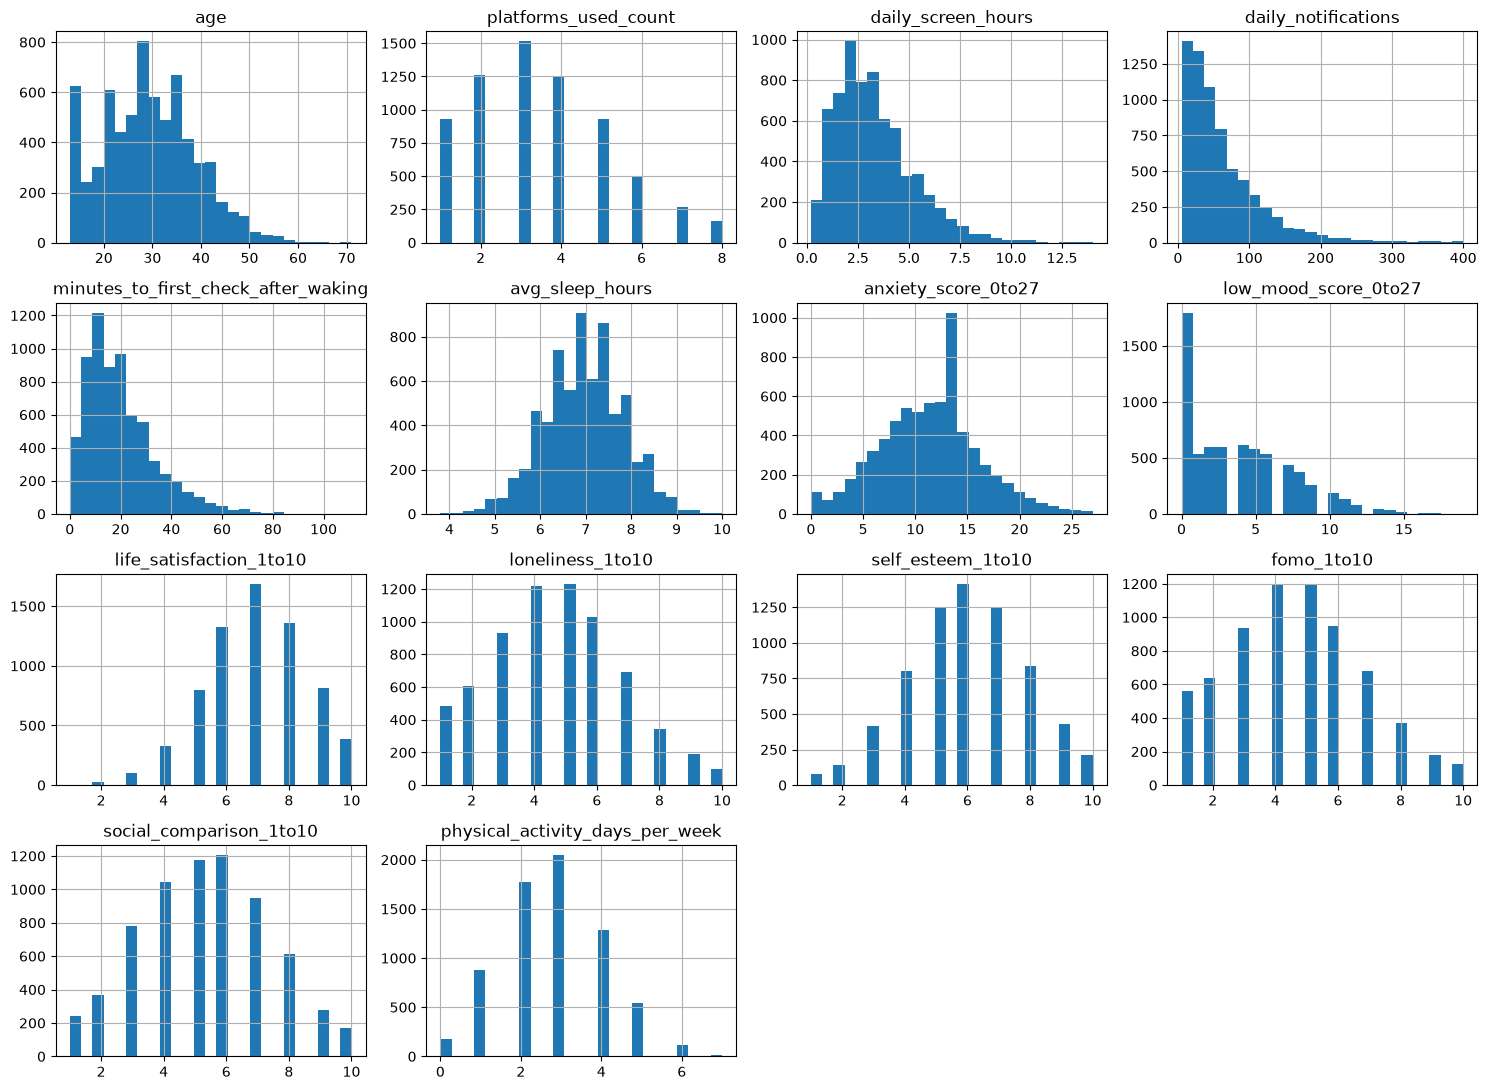

In [35]:
num.hist(figsize=(15, 11), bins=25)
plt.tight_layout()
plt.show()

# con le variabili numeriche, la distribuzione la studio e analizzo attraverso gli istogrammi

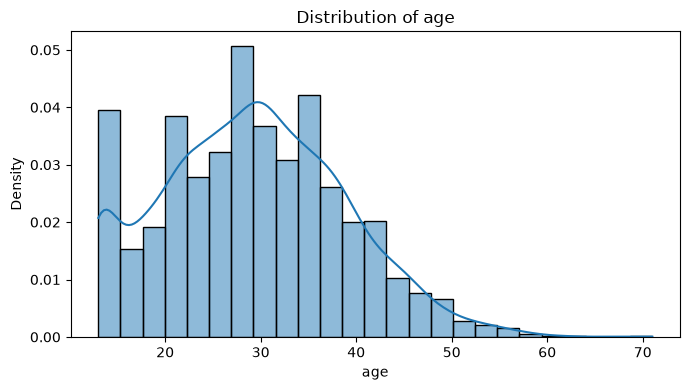

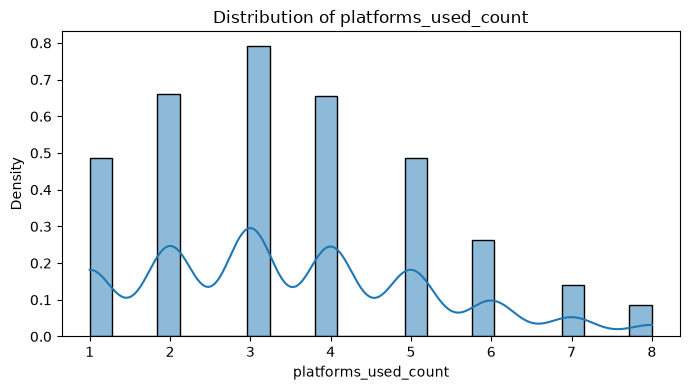

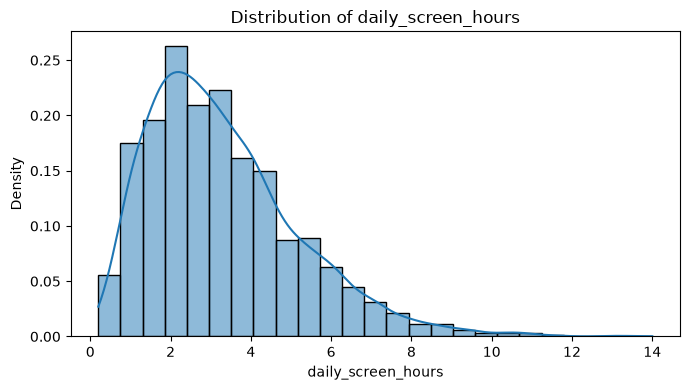

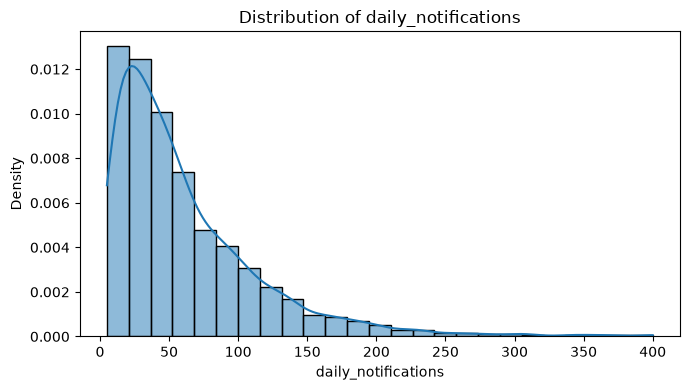

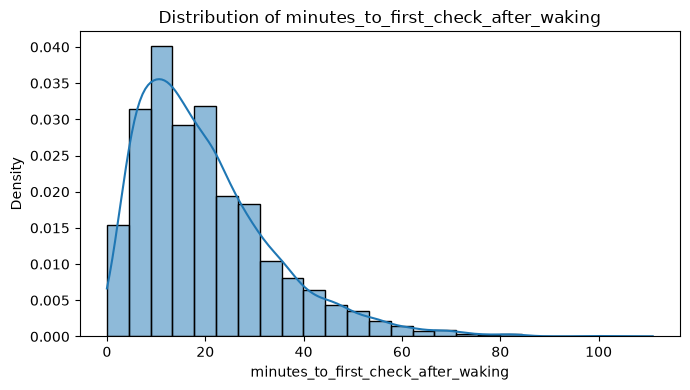

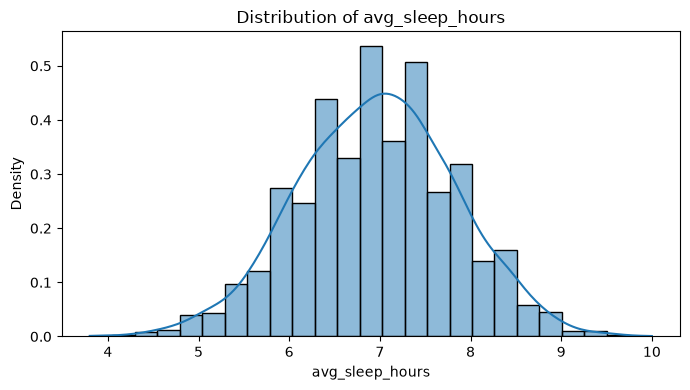

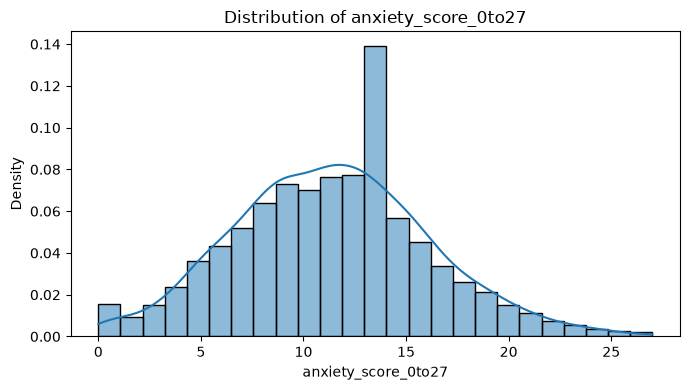

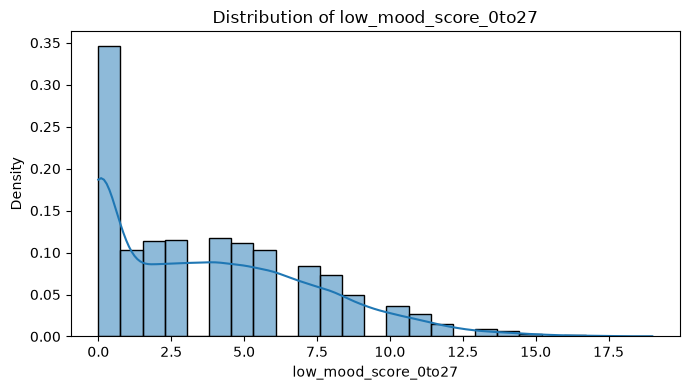

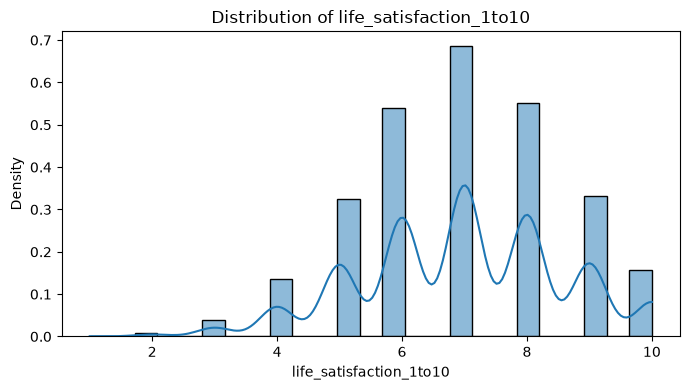

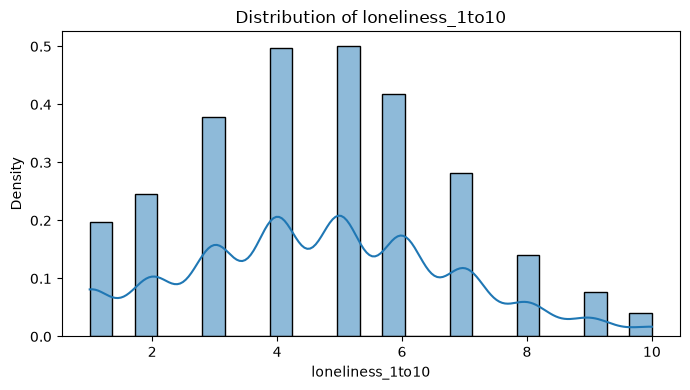

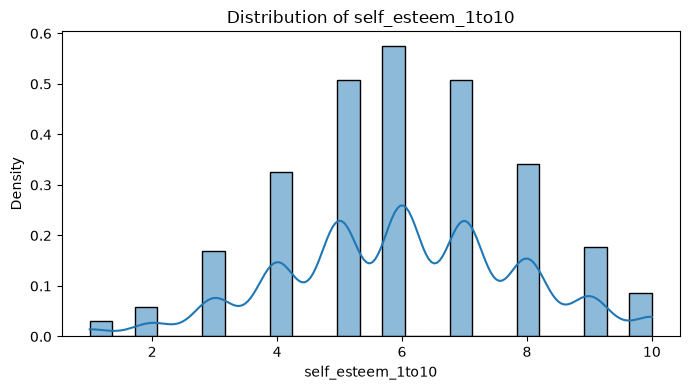

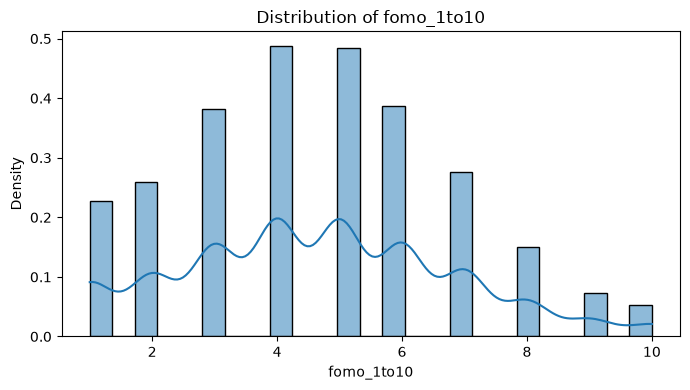

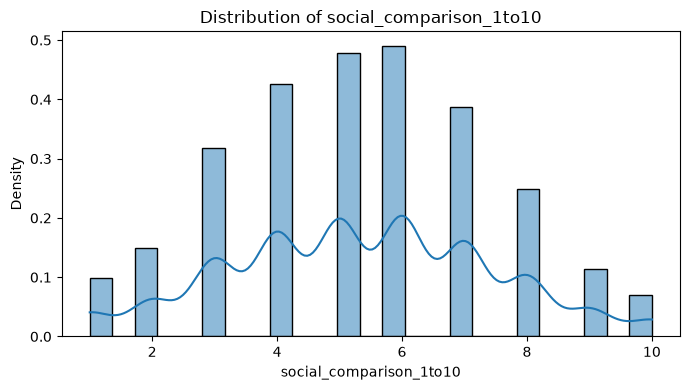

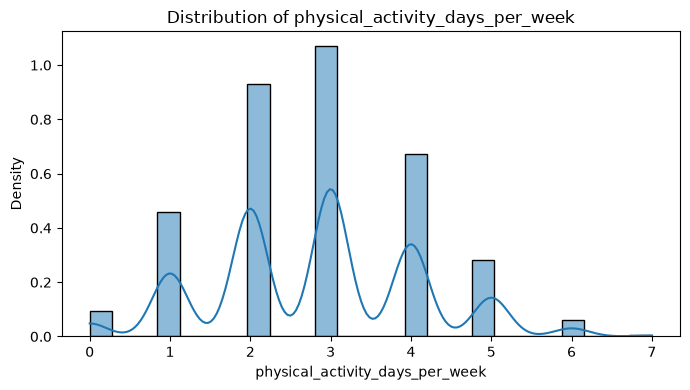

In [36]:
for col in num:
    plt.figure(figsize=(7, 4))
    sns.histplot(data = num, x = col, bins = 25, kde = True, stat = "density")

    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

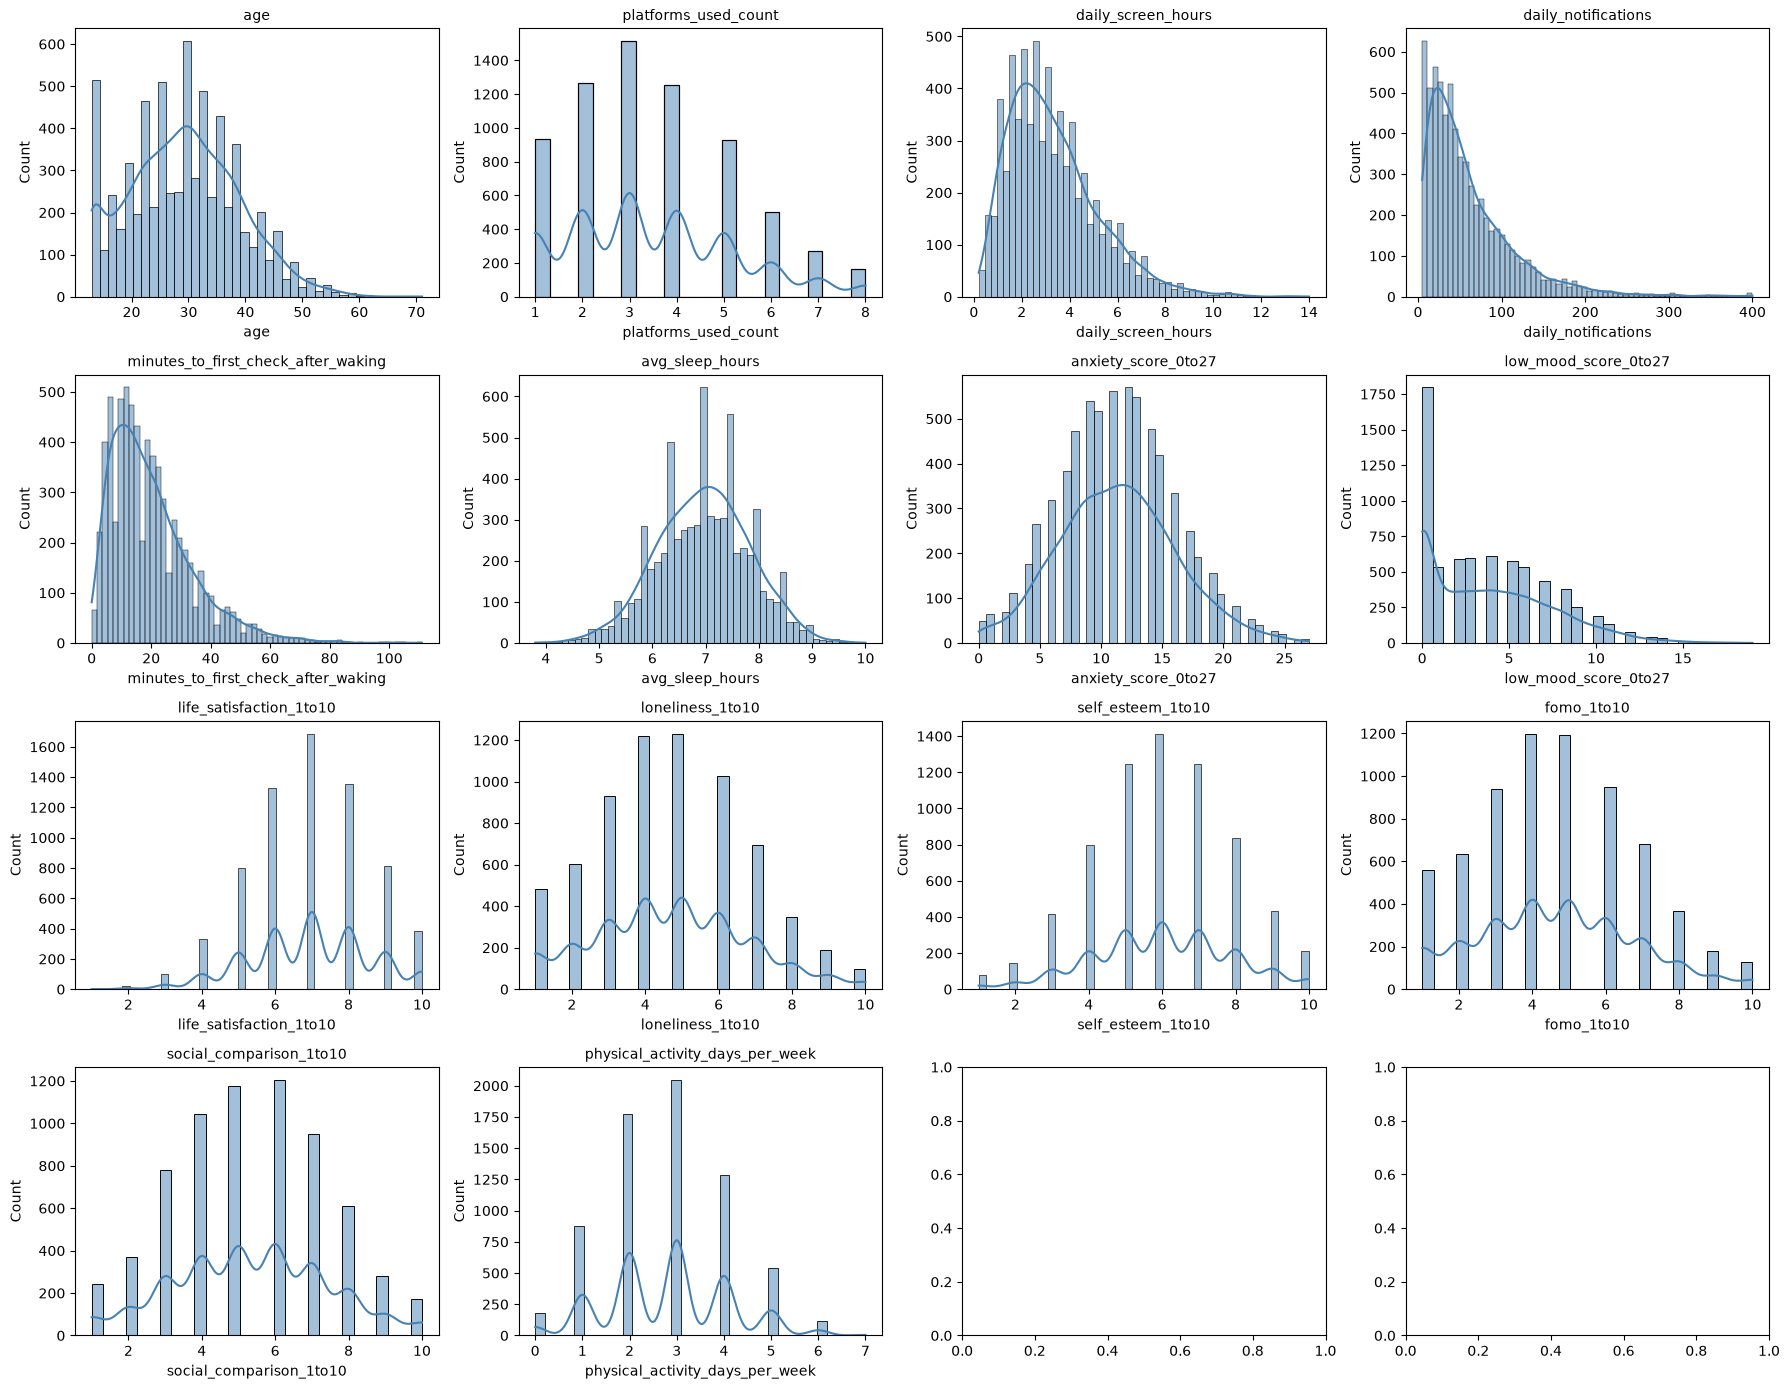

In [37]:
# con aiuto AI
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, num):
    sns.histplot(df_clean[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)

for ax in axes[len(num):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

CATEGORICAL VARIABLES DISTRIBUTION

In [38]:
# categorical variables distribution -> countplot
cat = df_clean.select_dtypes(exclude='number')
cat = cat.drop(columns=['participant_id'])

cat = cat.drop(columns=['gender_missing','sleep_missing'])
cat.columns

Index(['gender', 'occupation', 'region', 'most_used_platform',
       'night_time_use', 'primary_purpose', 'uses_screen_time_limits',
       'attempted_digital_detox', 'seeks_mental_health_support',
       'wellbeing_band'],
      dtype='str')

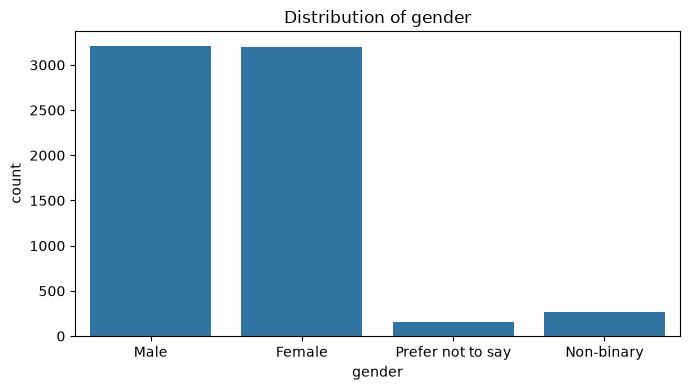

In [39]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean,x='gender')

plt.title('Distribution of gender')
plt.tight_layout()
plt.show()

In [40]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean,x='age_group')

plt.title('Distribution of age')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `age_group` for `x`. An entry with this name does not appear in `data`.

<Figure size 700x400 with 0 Axes>

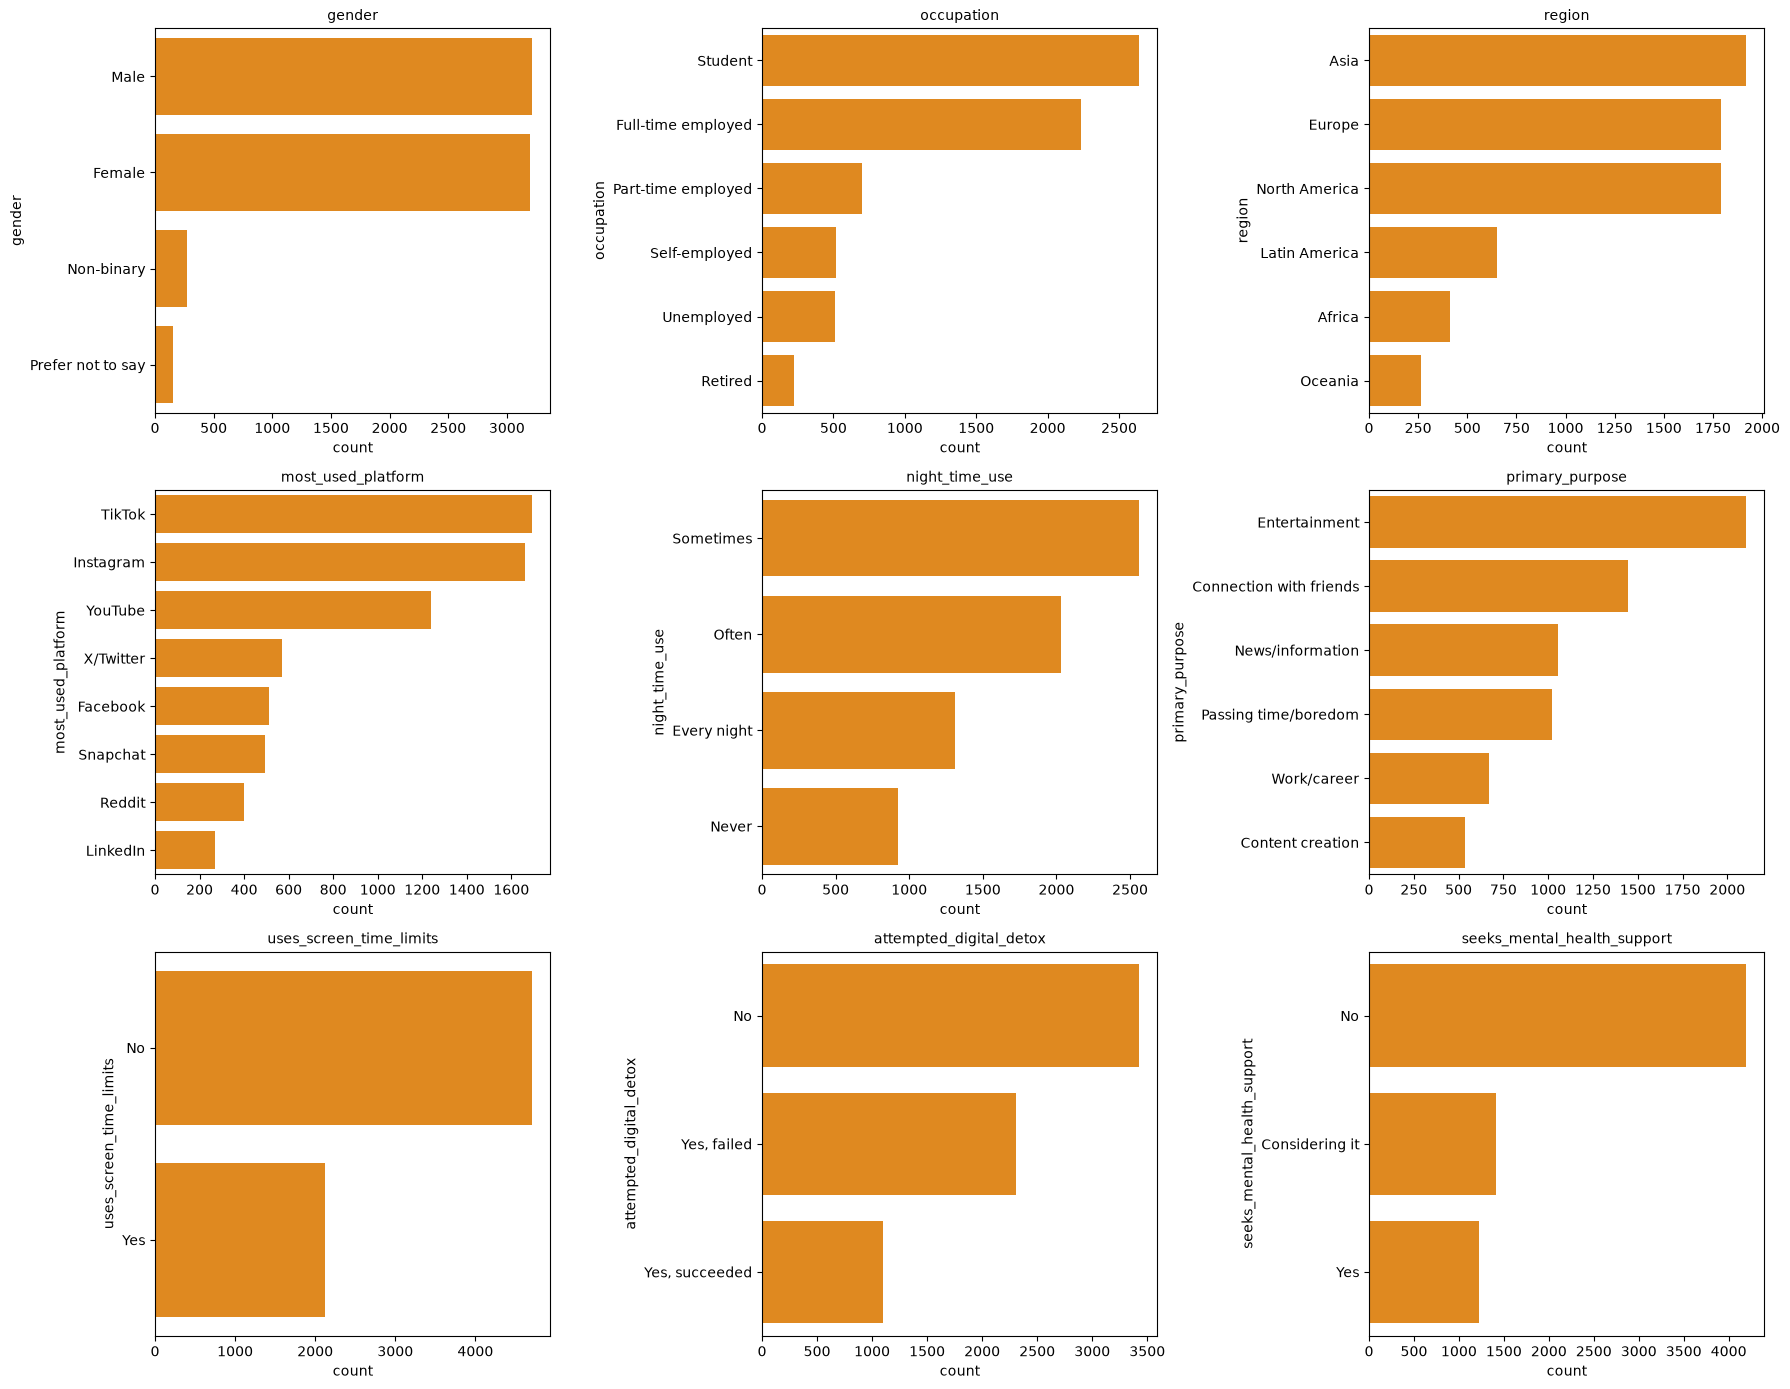

In [41]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, cat):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, ax=ax, color="darkorange")
    ax.set_title(col, fontsize=10)

for ax in axes[len(cat):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [42]:
corr = num.corr()
corr

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
age,1.000000,0.016643,0.006988,0.014359,-0.016594,0.003002,-0.004752,-0.006887,0.011505,-0.012668,-0.013094,0.005070,-0.006385,-0.014267
platforms_used_count,0.016643,1.000000,-0.014802,-0.010478,-0.005965,0.007880,-0.002155,-0.004563,-0.012794,-0.145617,0.011645,-0.015086,-0.009039,-0.013808
daily_screen_hours,0.006988,-0.014802,1.000000,0.605423,0.009192,-0.382168,0.526774,-0.357931,-0.364233,0.342654,-0.295588,0.431086,0.351211,0.003103
daily_notifications,0.014359,-0.010478,0.605423,1.000000,-0.022836,-0.237595,0.324303,-0.221500,-0.220917,0.211362,-0.183728,0.254688,0.202033,-0.003115
minutes_to_first_check_after_waking,-0.016594,-0.005965,0.009192,-0.022836,1.000000,-0.002073,0.011109,-0.010588,-0.001493,0.016948,-0.020932,-0.013712,-0.010186,0.004557
avg_sleep_hours,0.003002,0.007880,-0.382168,-0.237595,-0.002073,1.000000,-0.257016,0.187508,0.268154,-0.133463,0.124740,-0.167118,-0.134470,0.003011
anxiety_score_0to27,-0.004752,-0.002155,0.526774,0.324303,0.011109,-0.257016,1.000000,-0.206443,-0.220151,0.179982,-0.151697,0.236543,0.175657,-0.005211
low_mood_score_0to27,-0.006887,-0.004563,-0.357931,-0.221500,-0.010588,0.187508,-0.206443,1.000000,0.134213,-0.127058,0.111199,-0.157509,-0.126740,0.007134
life_satisfaction_1to10,0.011505,-0.012794,-0.364233,-0.220917,-0.001493,0.268154,-0.220151,0.134213,1.000000,-0.138002,0.102107,-0.161877,-0.143884,0.002859
loneliness_1to10,-0.012668,-0.145617,0.342654,0.211362,0.016948,-0.133463,0.179982,-0.127058,-0.138002,1.000000,-0.113212,0.150742,0.113852,0.022782


# BIVARIATE ANALYSIS

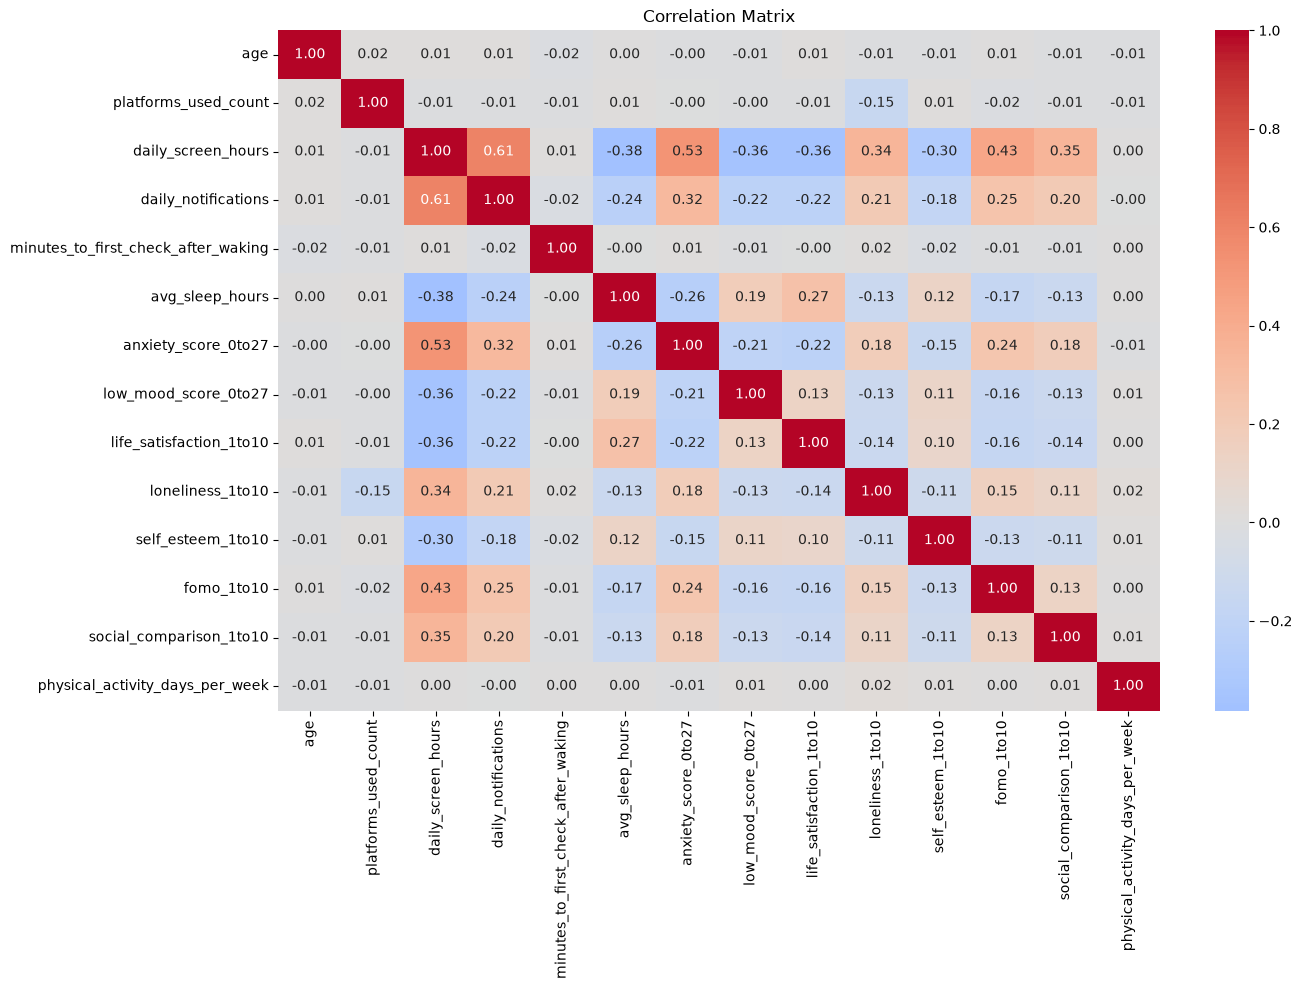

In [43]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Most correlated variables: 
- daily notifications - daily screen hours 0.61
- daily screen hours - anxiety score 1to27 0.53
- daily screen hours - fomo 1to10          0.43
- daily screen hours - avg_sleep_hours    -0.38 

# BOXPLOT

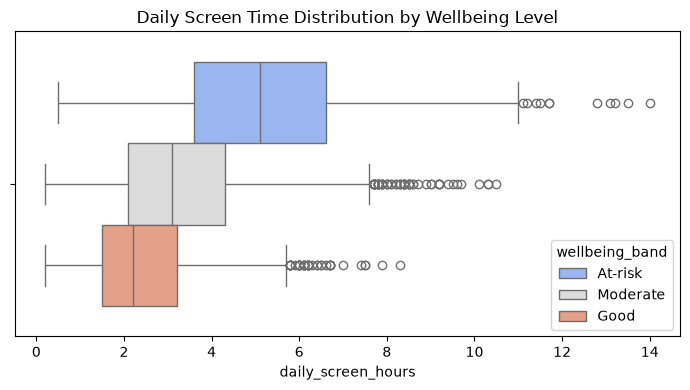

In [44]:
plt.figure(figsize=(7,4))
sns.boxplot(x="daily_screen_hours", hue="wellbeing_band",data=df_clean, palette = "coolwarm", legend = True)
plt.title("Daily Screen Time Distribution by Wellbeing Level")
plt.tight_layout()
plt.show()

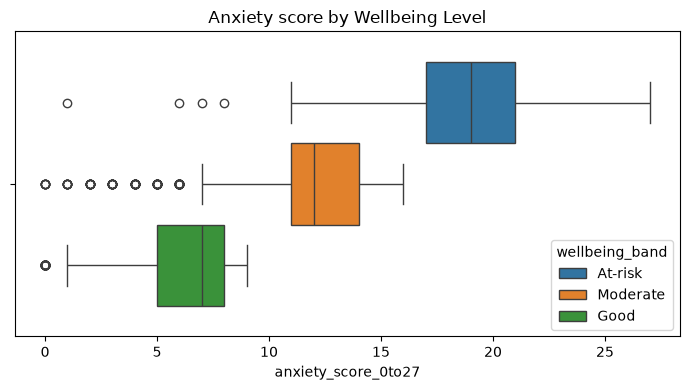

In [45]:
plt.figure(figsize=(7,4))
sns.boxplot(x="anxiety_score_0to27", hue="wellbeing_band",data=df_clean, legend = True)
plt.title("Anxiety score by Wellbeing Level")
plt.tight_layout()
plt.show()

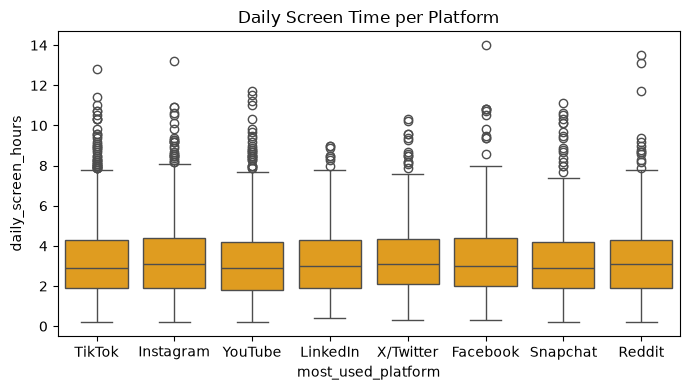

In [46]:
plt.figure(figsize=(7,4))
sns.boxplot(x="most_used_platform", y="daily_screen_hours",data=df_clean, color = "orange")
plt.title("Daily Screen Time per Platform")
plt.tight_layout()
plt.show()

In [47]:
plt.figure(figsize=(10,4))
sns.boxplot(x="anxiety_score_0to27", hue="age_group",data=df_clean, legend = True)
plt.title("Anxiety score by Age group")
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `age_group` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x400 with 0 Axes>

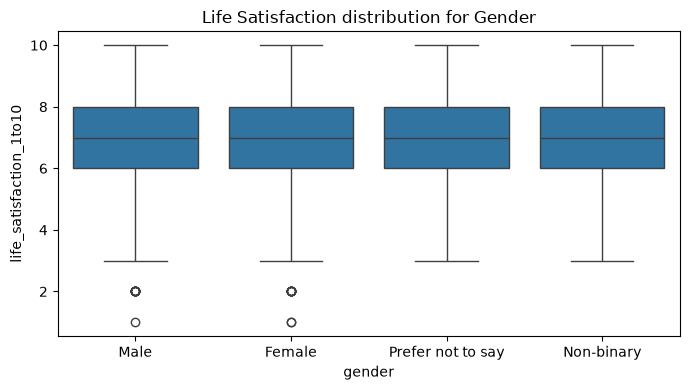

In [48]:
plt.figure(figsize=(7,4))
sns.boxplot(x='gender',y='life_satisfaction_1to10',data=df_clean)
plt.title("Life Satisfaction distribution for Gender")
plt.tight_layout()
plt.show()

# SCATTER PLOT

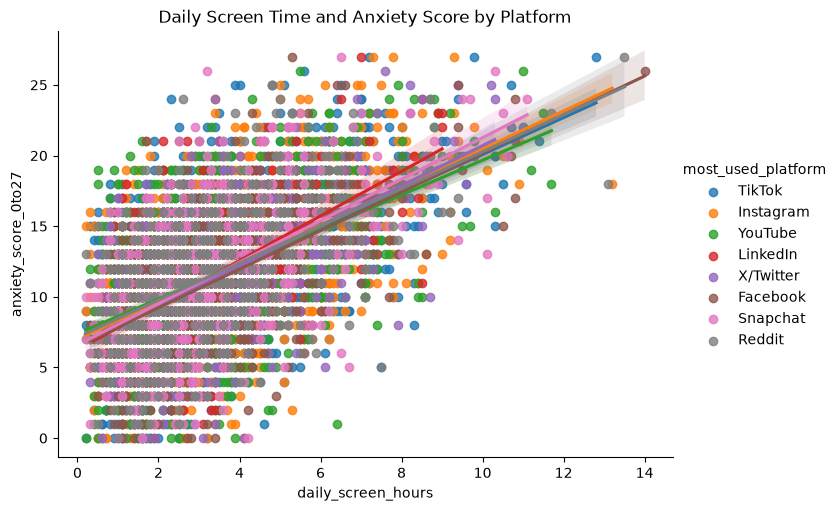

In [49]:
sns.lmplot(
    x="daily_screen_hours",
    y="anxiety_score_0to27",
    data=df_clean,
    hue="most_used_platform",
    height=5,
    aspect=1.4)

plt.title("Daily Screen Time and Anxiety Score by Platform")
plt.show()

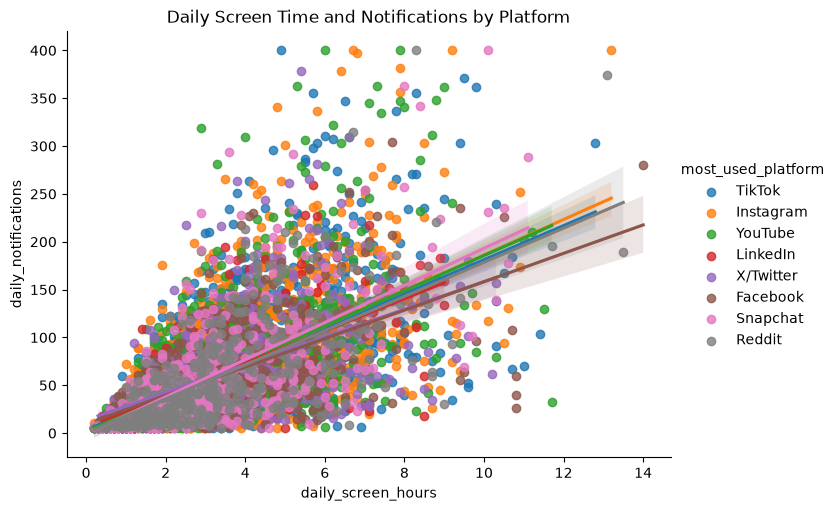

In [50]:
sns.lmplot(
    x="daily_screen_hours",
    y="daily_notifications",
    data=df_clean,
    hue="most_used_platform",
    height=5,
    aspect=1.4
)

plt.title("Daily Screen Time and Notifications by Platform")
plt.show()

In [51]:
df_final = df_clean.drop(columns=['gender_missing', 'sleep_missing'])
df_final.to_csv('updated_dataset.csv', index=False)

# MACHINE LEARNING MODELS

In [52]:
# let's define features
X = df_clean[['age', 'gender', 'occupation', 'region', 'most_used_platform',
              'platforms_used_count', 'daily_screen_hours', 'daily_notifications',
              'night_time_use', 'minutes_to_first_check_after_waking',
              'primary_purpose', 'uses_screen_time_limits', 'avg_sleep_hours', 'attempted_digital_detox','social_comparison_1to10',
              'physical_activity_days_per_week', 'fomo_1to10']]

# target variable
y = df_clean['wellbeing_band']

In [53]:
X.info()

<class 'pandas.DataFrame'>
Index: 6827 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  6827 non-null   int64  
 1   gender                               6827 non-null   str    
 2   occupation                           6827 non-null   str    
 3   region                               6827 non-null   str    
 4   most_used_platform                   6827 non-null   str    
 5   platforms_used_count                 6827 non-null   int64  
 6   daily_screen_hours                   6827 non-null   float64
 7   daily_notifications                  6827 non-null   int64  
 8   night_time_use                       6827 non-null   str    
 9   minutes_to_first_check_after_waking  6827 non-null   int64  
 10  primary_purpose                      6827 non-null   str    
 11  uses_screen_time_limits              6827 non-

In [54]:
# preprocessing for models like logistic regression, random forest and svc (not fot XGboost)

In [55]:
# str variables in "categoricy" and trasform theme in dummies
# if there are, replace missing values
# scaling 

In [56]:
# categorical variables in "category"

categorical_features = [
    'gender', 'occupation', 'region', 'most_used_platform', 'night_time_use',
    'primary_purpose', 'uses_screen_time_limits', 'attempted_digital_detox'
]
for c in categorical_features:
    X[c] = X[c].astype("category")

In [57]:
# one - hot encoding
X = pd.get_dummies(X, categorical_features, drop_first=True, dtype=int)

In [58]:
X.info()

<class 'pandas.DataFrame'>
Index: 6827 entries, 0 to 6999
Data columns (total 40 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   age                                     6827 non-null   int64  
 1   platforms_used_count                    6827 non-null   int64  
 2   daily_screen_hours                      6827 non-null   float64
 3   daily_notifications                     6827 non-null   int64  
 4   minutes_to_first_check_after_waking     6827 non-null   int64  
 5   avg_sleep_hours                         6827 non-null   float64
 6   social_comparison_1to10                 6827 non-null   int64  
 7   physical_activity_days_per_week         6827 non-null   int64  
 8   fomo_1to10                              6827 non-null   int64  
 9   gender_Male                             6827 non-null   int64  
 10  gender_Non-binary                       6827 non-null   int64  
 11  gender_

# LOGISTIC REGRESSION

In [59]:
X_train_lg, X_test_lg, y_train_lg, y_test_lg = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [60]:
scaler = StandardScaler()
X_train_lg = scaler.fit_transform(X_train_lg)
X_test_lg  = scaler.transform(X_test_lg)

In [61]:
logmodel = LogisticRegression(class_weight="balanced", max_iter=1000,  random_state=42)

In [62]:
logmodel.fit(X_train_lg, y_train_lg)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [63]:
predictions_lg = logmodel.predict(X_test_lg)

In [64]:
print(classification_report(y_test_lg,predictions_lg))

              precision    recall  f1-score   support

     At-risk       0.33      0.61      0.43       191
        Good       0.47      0.70      0.56       440
    Moderate       0.61      0.29      0.40       735

    accuracy                           0.47      1366
   macro avg       0.47      0.53      0.46      1366
weighted avg       0.52      0.47      0.45      1366



In [65]:
print(confusion_matrix(y_test_lg,predictions_lg))

[[116  27  48]
 [ 40 307  93]
 [194 325 216]]


<Figure size 800x600 with 0 Axes>

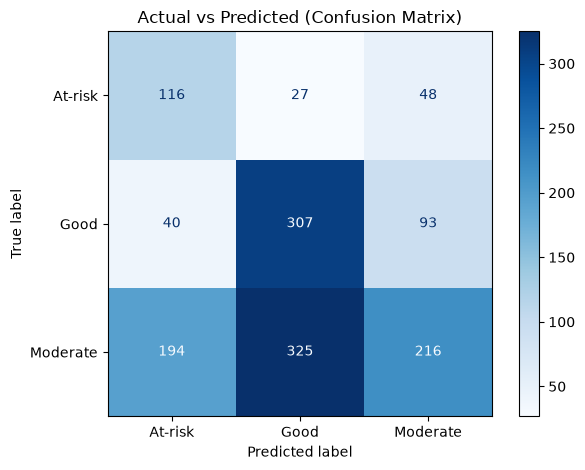

In [66]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test_lg,predictions_lg, cmap='Blues')
plt.title('Actual vs Predicted (Confusion Matrix)')
plt.tight_layout()
plt.show()

# RANDOM FOREST

In [67]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [68]:
rfc = RandomForestClassifier(
    n_estimators=300,         
    max_depth=8,               
    min_samples_leaf=5,        
    class_weight="balanced",   
    random_state=42,           
    n_jobs=-1                  
)

In [69]:
rfc.fit(X_train_rf, y_train_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featu

In [70]:
predictions_rf = rfc.predict(X_test_rf)

In [71]:
print(classification_report(y_test_rf,predictions_rf))

              precision    recall  f1-score   support

     At-risk       0.35      0.60      0.44       191
        Good       0.45      0.75      0.56       440
    Moderate       0.60      0.25      0.36       735

    accuracy                           0.46      1366
   macro avg       0.47      0.53      0.45      1366
weighted avg       0.52      0.46      0.43      1366



In [72]:
print(confusion_matrix(y_test_rf,predictions_rf))

[[114  29  48]
 [ 35 332  73]
 [174 376 185]]


In [73]:
importance_rf = pd.DataFrame({"feature": X_train_rf.columns,"importance": rfc.feature_importances_}).sort_values(by="importance", ascending=False) 
importance_rf

,feature,importance
2,daily_screen_hours,0.389042
3,daily_notifications,0.143857
5,avg_sleep_hours,0.093696
8,fomo_1to10,0.065409
6,social_comparison_1to10,0.043276
4,minutes_to_first_check_after_waking,0.042203
0,age,0.034949
1,platforms_used_count,0.024187
7,physical_activity_days_per_week,0.019419
31,night_time_use_Sometimes,0.008773


In [74]:
# permutation

In [75]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rfc, X_test_rf, y_test_rf,
    n_repeats=10,          # ripete lo shuffle 10 volte per stabilità della stima
    random_state=42,
    n_jobs=-1,
    scoring="f1_macro"     # stessa metrica che stiamo usando per valutare i modelli
)

importance_perm = pd.DataFrame({
    "feature": X_test_rf.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

importance_perm

,feature,importance_mean,importance_std
2,daily_screen_hours,0.098364,0.009029
14,occupation_Self-employed,0.003365,0.001500
12,occupation_Part-time employed,0.001838,0.001482
3,daily_notifications,0.001482,0.006699
29,night_time_use_Never,0.001164,0.002383
6,social_comparison_1to10,0.001055,0.004485
22,most_used_platform_Instagram,0.000656,0.001317
8,fomo_1to10,0.000609,0.004067
0,age,0.000411,0.003783
16,occupation_Unemployed,0.000280,0.000807


In [76]:
importance_perm.to_csv('feature_importance.csv', index=False)